## Exploratory Data Analysis (EDA)

Exploratory Data Analysis for the phishing email classification project.
Dataset: `Phishing_Email.csv` — 18,650 emails labelled as *Phishing Email* or *Safe Email*.

In [1]:
import pandas as pd

In [61]:
df = pd.read_csv('../data/raw/Phishing_Email.csv')

In [62]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [63]:
df.shape

(18650, 3)

In [64]:
df.rename(columns={'Unnamed: 0': 'Id', 'Email Text': 'Body', 'Email Type': 'Target'}, inplace=True)
df.head()

,Id,Body,Target
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [65]:
df['Body'].isnull().sum()

np.int64(16)

- as we got only 16 null values in the Body column, we can drop those rows as they won't contribute much to our analysis and model training.

In [66]:
df.dropna(subset=['Body'], inplace=True)
df.shape

(18634, 3)

In [67]:
# Body contains empty strings, we can drop those rows as well.
df = df[~df['Body'].str.contains('empty', case=False, na=False)]

In [68]:
# Clean and normalize text
import html
import re

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", re.IGNORECASE)
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
NON_PRINTABLE_PATTERN = re.compile(r"[^\x20-\x7E]+")


def normalize_body(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Convert HTML entities and strip tags
    text = html.unescape(text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    # Normalize URLs and emails
    text = URL_PATTERN.sub(" <URL> ", text)
    text = EMAIL_PATTERN.sub(" <EMAIL> ", text)
    # Remove non-printable characters
    text = NON_PRINTABLE_PATTERN.sub(" ", text)
    # Collapse whitespace and lowercase
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


df["Body"] = df["Body"].apply(normalize_body)
# Drop rows that became empty after cleaning
cleaned_before = df.shape[0]
df = df[df["Body"] != ""]
# Deduplicate on normalized body text
before_dedup = df.shape[0]
df = df.drop_duplicates(subset=["Body"]).reset_index(drop=True)
print(f"Dropped {cleaned_before - before_dedup} empty bodies after cleaning.")
print(f"Dropped {before_dedup - df.shape[0]} duplicate bodies after cleaning.")

Dropped 3 empty bodies after cleaning.
Dropped 650 duplicate bodies after cleaning.


In [69]:
df.tail()

,Id,Body,Target
17335,18645,rick moen a crit:> > i'm confused. i thought i...,Safe Email
17336,18646,date a lonely housewife always wanted to date ...,Phishing Email
17337,18647,request submitted : access request for anita ....,Safe Email
17338,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
17339,18649,press clippings - letter on californian utilit...,Safe Email


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud  # For generating word clouds based on text data which can help visualize the most common words in phishing and safe emails.

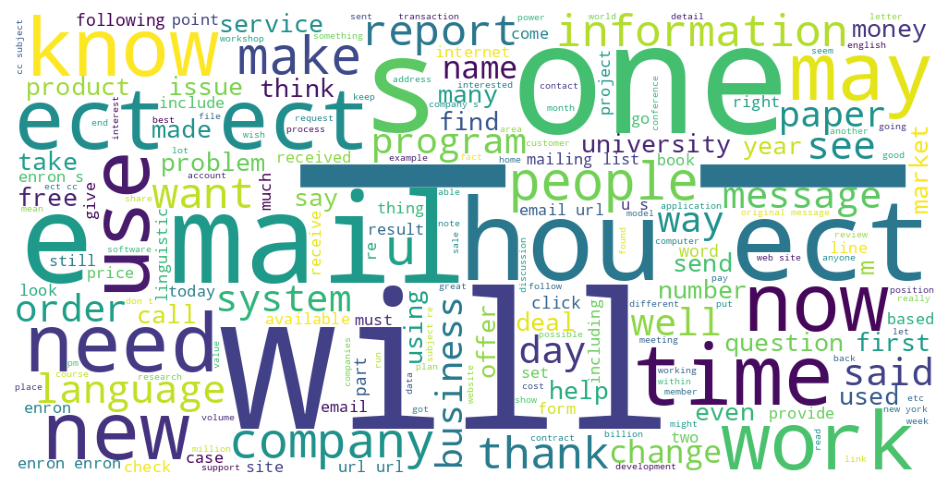

In [71]:
if HAS_WORDCLOUD:
    text = " ".join(df['Body'].dropna().astype(str))
    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

- Based on WordCloud, we can see that the most common words in the email bodies are "email", "information", "one", "use", "language", "may", "now", "time" and "will". These words are quite generic and do not provide much insight into the specific characteristics of phishing emails. However, they do indicate that the dataset contains a variety of email content, which may include both phishing and safe emails. To gain more insights, we can further analyze the distribution of phishing and safe emails for imbalance dataset.

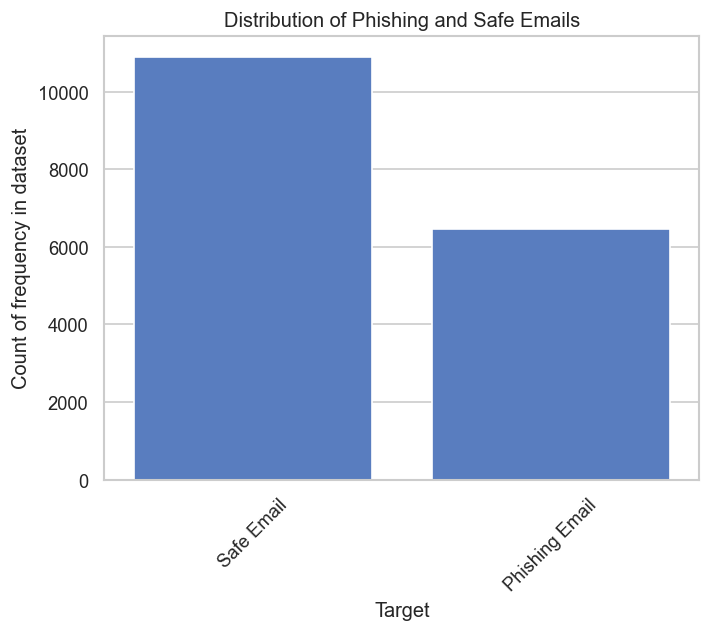

In [72]:
# Distribution of Phishing and Safe Emails
sns.countplot(x='Target', data=df)
plt.title('Distribution of Phishing and Safe Emails')
plt.xlabel('Target')
plt.ylabel('Count of frequency in dataset')
plt.xticks(rotation=45)
plt.show()

- Let's convert the Target column to binary labels for easier analysis and modeling. We can map "Phishing Email" to 1 and "Safe Email" to 0.

In [73]:
df['Target'] = df['Target'].map({'Phishing Email': 1, 'Safe Email': 0})
df.head()

,Id,Body,Target
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,1,the other side of * galicismos * * galicismo *...,0
2,2,re : equistar deal tickets are you still avail...,0
3,3,hello i am your hot lil horny toy. i am the on...,1
4,4,software at incredibly low prices ( 86 % lower...,1


## 1. Class Balance Analysis

Check whether the dataset is imbalanced — this drives decisions on class weights, oversampling (SMOTE), or undersampling during training.

                Count  Percentage
Target                           
Safe Email      10890        62.8
Phishing Email   6450        37.2


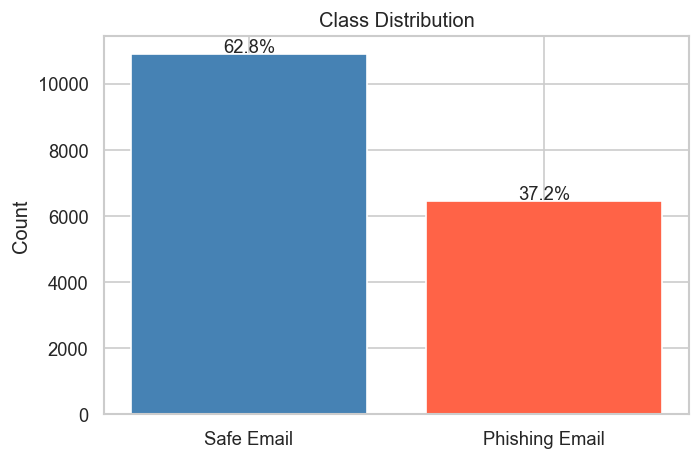

In [74]:
counts = df['Target'].value_counts()
pct = df['Target'].value_counts(normalize=True) * 100

balance = pd.DataFrame({'Count': counts, 'Percentage': pct.round(2)})
balance.index = balance.index.map({0: 'Safe Email', 1: 'Phishing Email'})
print(balance)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(balance.index, balance['Count'], color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, (idx, row) in enumerate(balance.iterrows()):
    ax.text(i, row['Count'] + 50, f"{row['Percentage']}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Text Length Analysis

Phishing emails often differ from safe emails in length. We look at character and word count distributions per class.

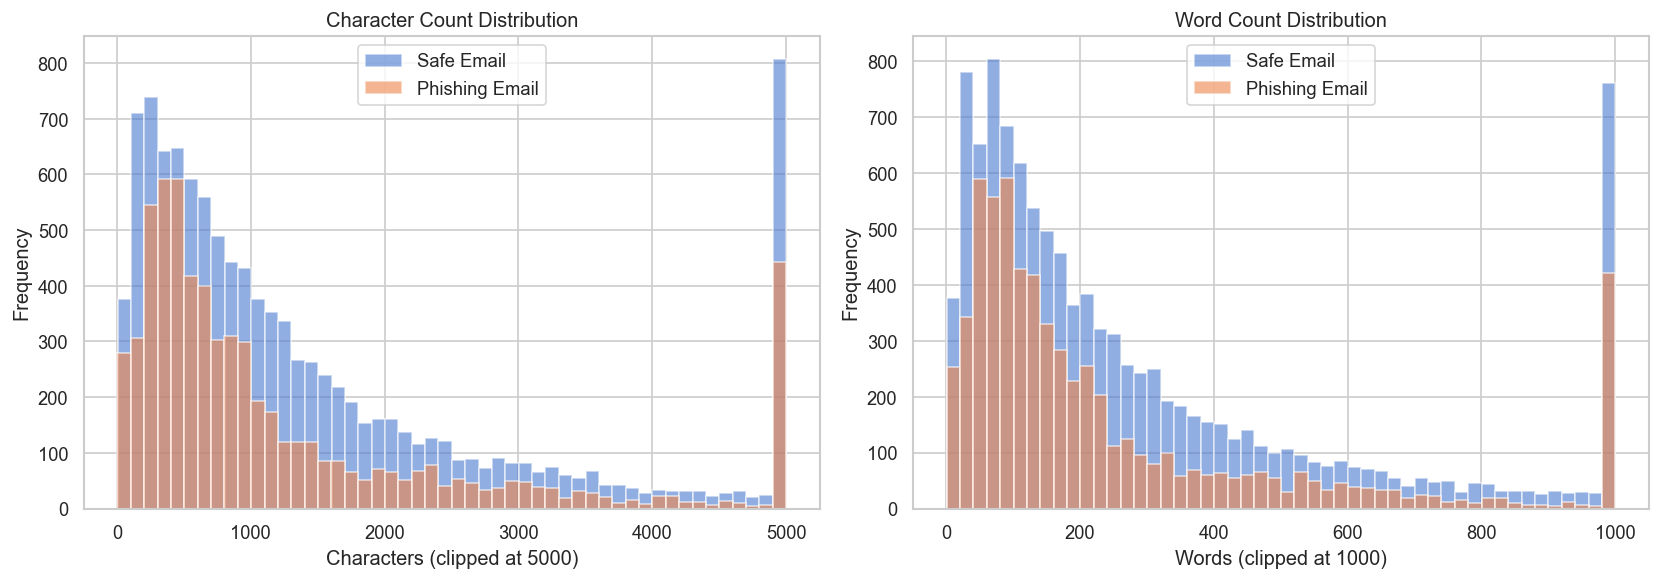

       char_count                                                       \
            count    mean     std  min    25%    50%     75%       max   
Target                                                                   
0         10890.0  1878.9  4094.2  5.0  441.0  959.0  1990.0  120761.0   
1          6450.0  1628.2  3342.4  4.0  385.0  731.0  1576.5  124244.0   

       word_count                                                  
            count   mean    std  min   25%    50%    75%      max  
Target                                                             
0         10890.0  366.1  793.1  1.0  83.0  182.0  391.0  23343.0  
1          6450.0  313.9  575.9  1.0  76.0  143.0  306.0  11569.0  


In [75]:
df['char_count'] = df['Body'].str.len()
df['word_count'] = df['Body'].str.split().str.len()

label_map = {0: 'Safe Email', 1: 'Phishing Email'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name in label_map.items():
    subset = df[df['Target'] == label]
    axes[0].hist(subset['char_count'].clip(upper=5000), bins=50, alpha=0.6, label=name)
    axes[1].hist(subset['word_count'].clip(upper=1000), bins=50, alpha=0.6, label=name)

axes[0].set_title('Character Count Distribution')
axes[0].set_xlabel('Characters (clipped at 5000)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words (clipped at 1000)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('Target')[['char_count', 'word_count']].describe().round(1))

## 3. Top N-gram Analysis per Class

Most frequent unigrams and bigrams for each class reveal vocabulary patterns. `<URL>` and `<EMAIL>` tokens appearing heavily in phishing is a strong signal.

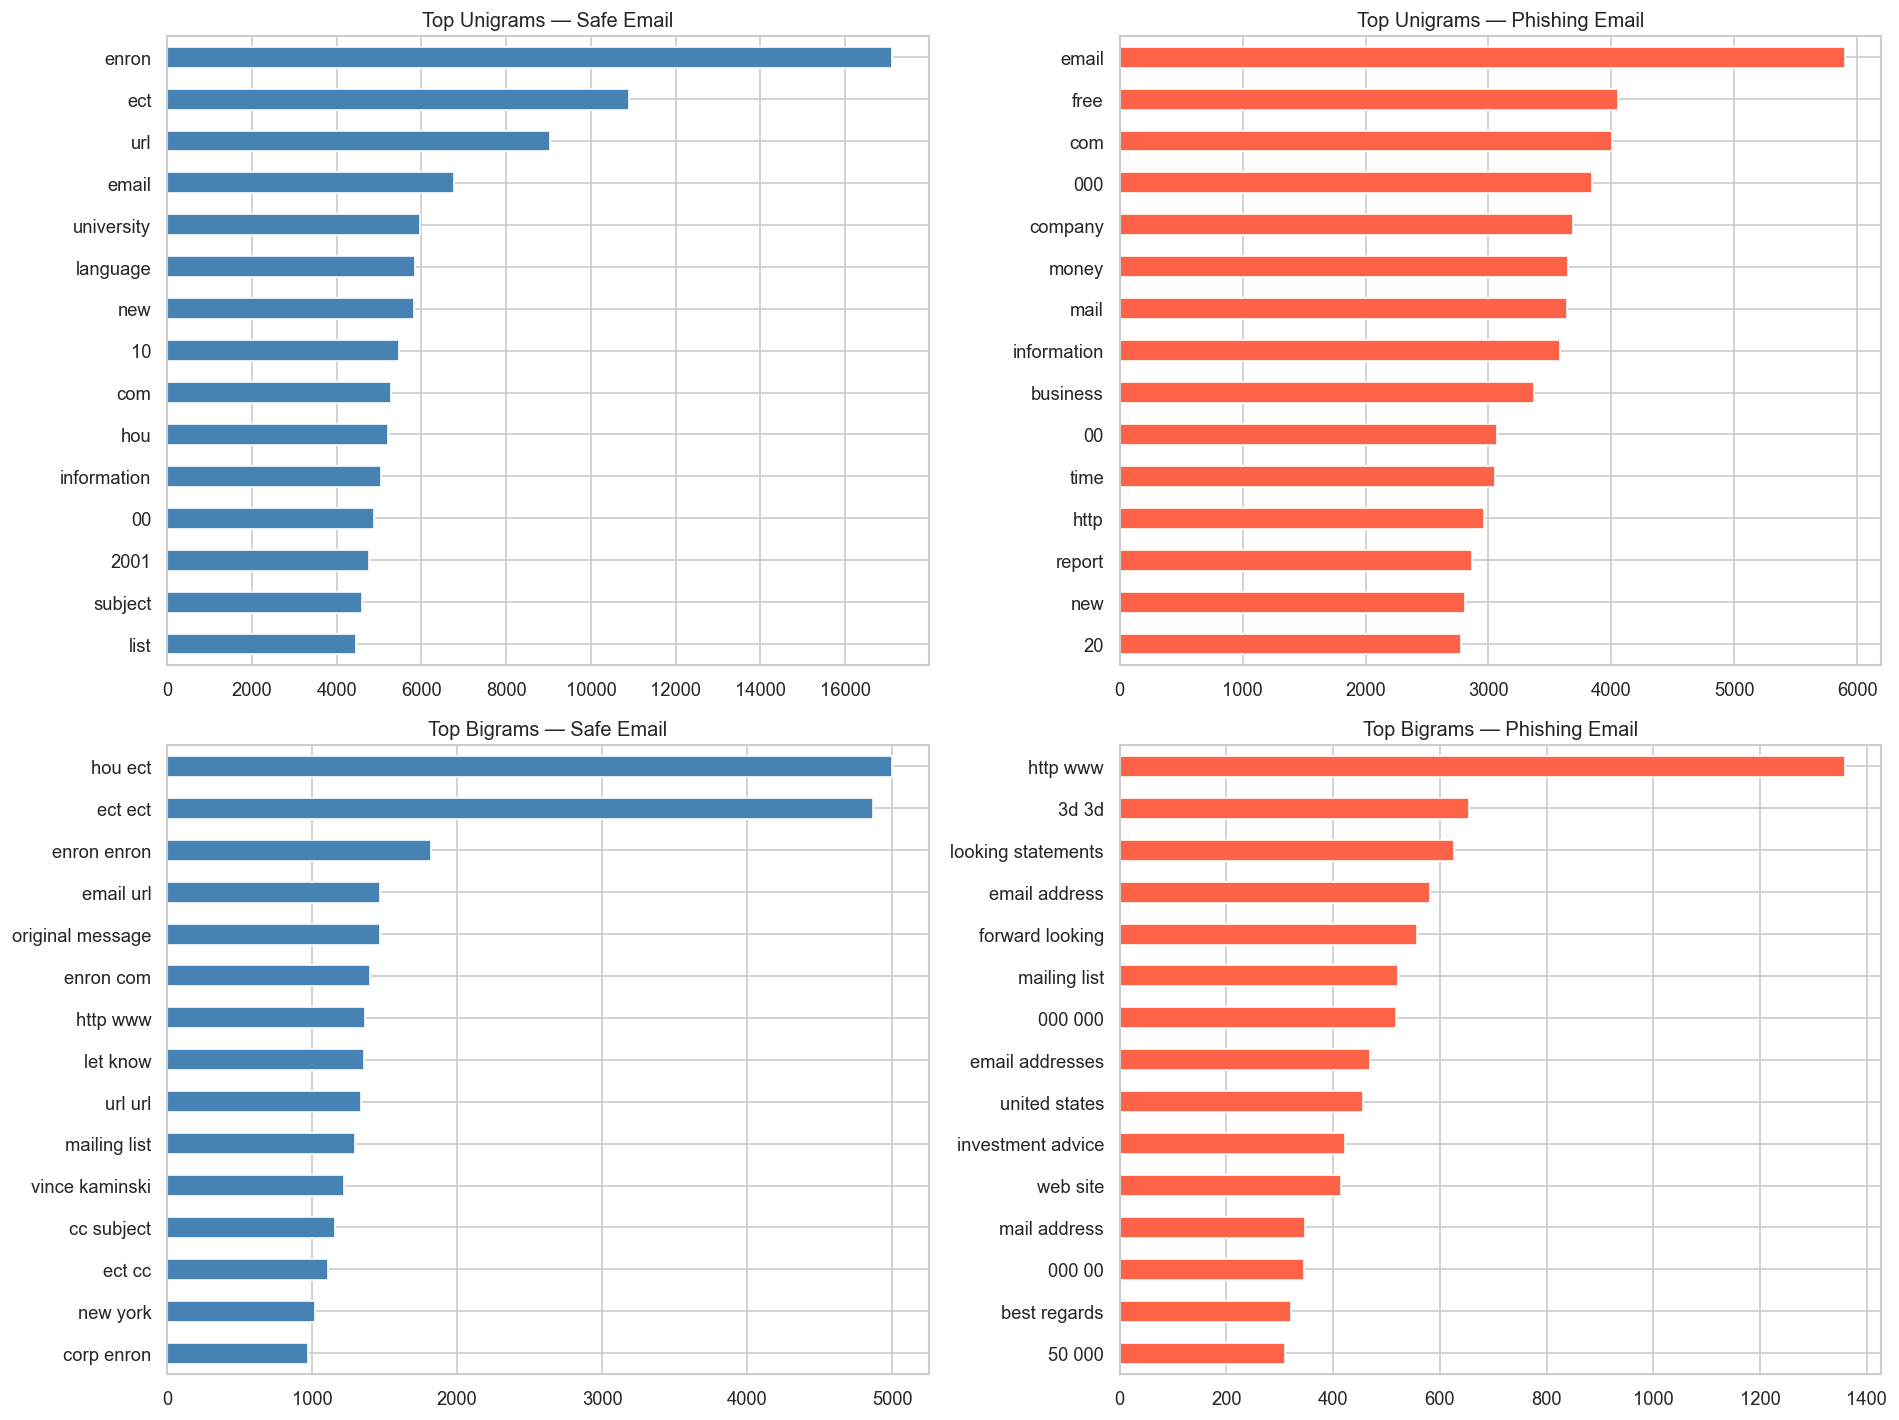

In [76]:
def top_ngrams(corpus, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=5000)
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return pd.Series(freqs, index=vocab).nlargest(top_k)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, (label, name) in enumerate(label_map.items()):
    corpus = df[df['Target'] == label]['Body']

    uni = top_ngrams(corpus, n=1)
    bi = top_ngrams(corpus, n=2)

    uni.plot(kind='barh', ax=axes[0][col], color='steelblue' if label == 0 else 'tomato')
    axes[0][col].set_title(f'Top Unigrams — {name}')
    axes[0][col].invert_yaxis()

    bi.plot(kind='barh', ax=axes[1][col], color='steelblue' if label == 0 else 'tomato')
    axes[1][col].set_title(f'Top Bigrams — {name}')
    axes[1][col].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Derived Feature Preview

Compute lightweight features from the normalized body to visualize their correlation with the target. These will feed into the feature engineering pipeline.

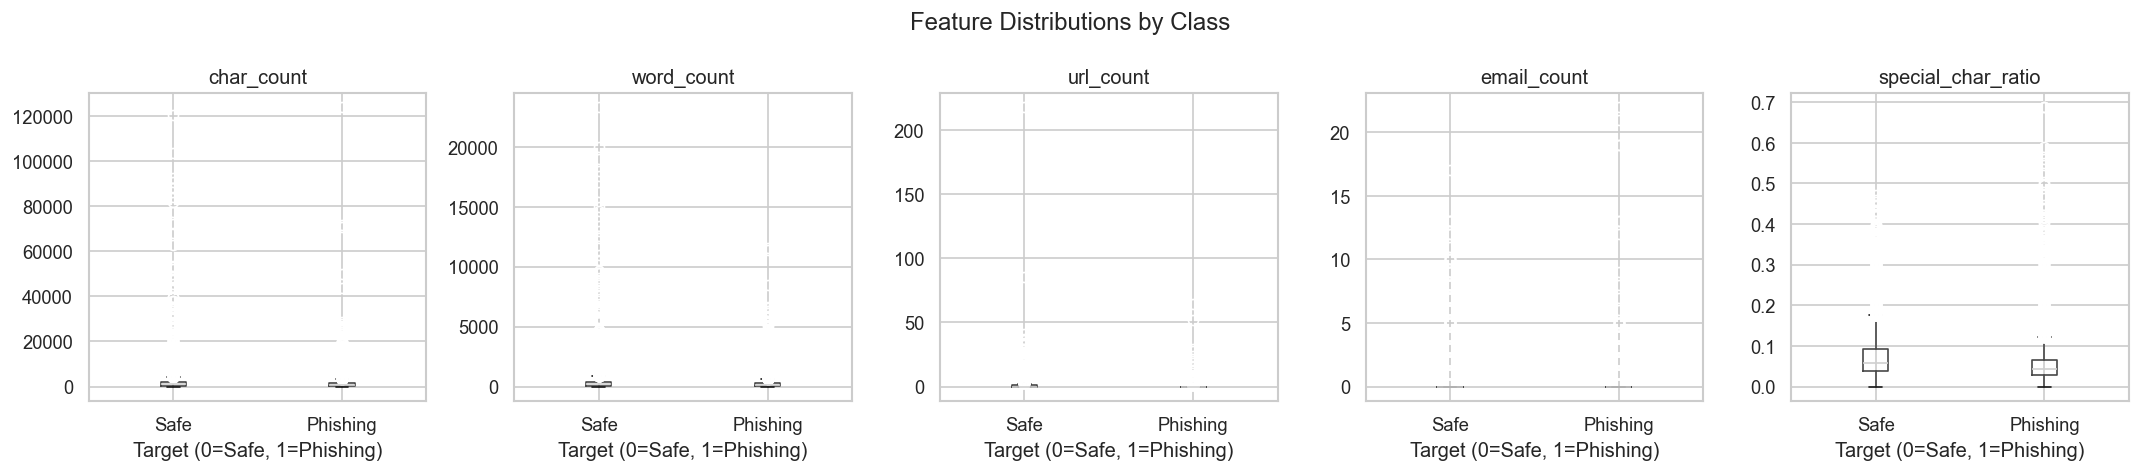

        char_count  word_count  url_count  email_count  special_char_ratio
Target                                                                    
0         1878.901     366.088      0.727        0.368               0.075
1         1628.233     313.936      0.278        0.152               0.057


In [80]:
df['url_count'] = df['Body'].str.count(r'<url>')
df['email_count'] = df['Body'].str.count(r'<email>')
df['special_char_ratio'] = df['Body'].apply(
    lambda x: len(re.findall(r'[^a-z0-9\s]', x)) / max(len(x), 1)
)

features = ['char_count', 'word_count', 'url_count', 'email_count', 'special_char_ratio']

fig, axes = plt.subplots(1, len(features), figsize=(18, 4))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='Target', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('Target (0=Safe, 1=Phishing)')
    ax.set_xticklabels(['Safe', 'Phishing'])
plt.suptitle('Feature Distributions by Class')
plt.tight_layout()
plt.show()

print(df.groupby('Target')[features].mean().round(3))

## 5. Final Dataset Validation

Confirm no nulls, correct dtypes, and a clean shape before saving.

In [81]:
print("Shape:", df[['Id', 'Body', 'Target']].shape)
print("\nDtypes:")
print(df[['Id', 'Body', 'Target']].dtypes)
print("\nNull counts:")
print(df[['Id', 'Body', 'Target']].isnull().sum())
print("\nTarget value counts:")
print(df['Target'].value_counts())
assert df['Body'].str.strip().eq('').sum() == 0, "Empty bodies found!"
assert df['Target'].isin([0, 1]).all(), "Unexpected target values!"
print("\nAll checks passed.")

Shape: (17340, 3)

Dtypes:
Id        int64
Body        str
Target    int64
dtype: object

Null counts:
Id        0
Body      0
Target    0
dtype: int64

Target value counts:
Target
0    10890
1     6450
Name: count, dtype: int64

All checks passed.


## 6. Save Processed Dataset

Save only the columns needed downstream: `Id`, `Body` (cleaned), and `Target` (binary).

In [82]:
import os

output_path = '../data/processed/emails_clean.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df[['Id', 'Body', 'Target']].to_csv(output_path, index=False)
print(f"Saved {len(df):,} rows to {output_path}")

Saved 17,340 rows to ../data/processed/emails_clean.csv
